# Computational Finance Group 7 Assessment Notebook
### Group 7 Members
Daanish Muzaffar (7259472)  
Florian Niklas Hintz (7299289)  
Philip Boehnke (7383580)  
Walid Al-Nimah (6075417)

---
## 1. Setup

### Libraries & Dependencies

Loading all necessary libraries and `module.py`.

In [36]:
import importlib, sys, subprocess

required_packages = ['numpy', 'pandas', 'matplotlib', 'yahooquery', 'yfinance']

missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {", ".join(missing)} ...')
    for _flags in ([], ['--user'], ['--break-system-packages']):
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing] + _flags)
            break
        except subprocess.CalledProcessError:
            if _flags == ['--break-system-packages']:
                raise
    print('Installation complete.')
else:
    print('All dependencies satisfied.')

try:
    import module
    print('module.py loaded successfully.')
except ModuleNotFoundError:
    raise ImportError(
        'module.py was not found. Place it in the same directory as this notebook.'
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

importlib.reload(module);

All dependencies satisfied.
module.py loaded successfully.


### Load Price Data

We load adjusted close prices for XLF, XLB, XLK, and the S&P 500. 

In [37]:
import os, pathlib

# Three sector ETF baskets - one signal per basket
FINANCE_TICKERS    = ['XLF']   # Signal 0: MA Crossover - Financials
MATERIALS_TICKERS  = ['XLB']   # Signal 1: RSI          - Materials
TECHNOLOGY_TICKERS = ['XLK']   # Signal 2: Donchian     - Technology

ALL_TRADED = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS
tickers    = ALL_TRADED + ['^GSPC']

# Evaluation windows
IS_START   = '2010-01-01';  IS_END   = '2019-12-31'
OOS1_START = '2020-01-01';  OOS1_END = '2025-12-31'
OOS2_START = '2000-01-01';  OOS2_END = '2009-12-31'

data_dir = pathlib.Path('data')
data_dir.mkdir(exist_ok=True)

# IS + OOS1 window (2010-2025)
fin  = module.load_etf(FINANCE_TICKERS,    'xlf.csv',             IS_START, OOS1_END, data_dir)
mats = module.load_etf(MATERIALS_TICKERS,  'sector_etfs_ext.csv', IS_START, OOS1_END, data_dir)
tech = module.load_etf(TECHNOLOGY_TICKERS, 'sector_etfs_ext.csv', IS_START, OOS1_END, data_dir)
spx  = module.load_etf(['^GSPC'],           'spx.csv',             IS_START, OOS1_END, data_dir)

df_prices = fin.join(mats, how='outer').join(tech, how='outer').join(spx, how='outer')
df_prices = df_prices.ffill().dropna()
df_prices.index = pd.to_datetime(df_prices.index)

# OOS2 extended window (2000-2025) - loaded upfront for pre-sample stress test
_fin_ext  = module.load_etf(FINANCE_TICKERS,    'xlf_ext.csv',         OOS2_START, OOS1_END, data_dir)
_mats_ext = module.load_etf(MATERIALS_TICKERS,  'xlb_ext.csv',         OOS2_START, OOS1_END, data_dir)
_tech_ext = module.load_etf(TECHNOLOGY_TICKERS, 'xlk_ext.csv',         OOS2_START, OOS1_END, data_dir)
_spx_ext  = module.load_etf(['^GSPC'],           'spx_ext.csv',         OOS2_START, OOS1_END, data_dir)
df_prices_ext = (_fin_ext.join(_mats_ext, how='outer')
                          .join(_tech_ext, how='outer')
                          .join(_spx_ext,  how='outer')
                          .ffill().dropna())
df_prices_ext.index = pd.to_datetime(df_prices_ext.index)

_oos2_mask = (df_prices_ext.index >= OOS2_START) & (df_prices_ext.index <= OOS2_END)
df_oos2    = df_prices_ext[_oos2_mask]
df_pc_oos2 = module.make_price_changes(df_oos2)

# Merged price DataFrame: OOS2 (2000-2009) + IS+OOS1 (2010-2025)
df_prices_all = pd.concat([df_oos2, df_prices]).sort_index()

print(f'df_prices_all (2000-2025) : {df_prices_all.shape}  '
      f'({df_prices_all.index[0].date()} → {df_prices_all.index[-1].date()})')
print(f'Columns: {list(df_prices_all.columns)}')

df_prices_all (2000-2025) : (6538, 4)  (2000-01-03 → 2025-12-30)
Columns: ['XLF', 'XLB', 'XLK', '^GSPC']


---
## 2. Signals

## Signal 0: Moving Average Crossover (Financials ETF: XLF)

We use XLF because interest rate cycles create slow, persistent trends in financials - exactly what a long-window MA crossover captures.

$$s_t = 1 \iff \text{MA}_{w_s}(t) > \text{MA}_{w_l}(t), \qquad s_t = 0 \text{ otherwise}$$

IS-optimal parameters (research notebook 4.): $w_s = 20$, $w_l = 100$.

**Reference:** Brock, W., Lakonishok, J., & LeBaron, B. (1992). *Simple Technical Trading Rules and the Stochastic Properties of Stock Returns.* JF, 47(5), 1731–1764.

## Signal 1: Relative Strength Index (RSI) Mean Reversion (Materials ETF: XLB)

We use XLB because commodity cycles push Materials into recurring overbought/oversold extremes that revert once the PMI cycle turns. XLB ranked first in our 3. screening by Min OOS Sortino for RSI.

$$\text{RSI}_{14}(t) = 100 - \frac{100}{1 + \frac{\text{Avg Gain}_{14}}{\text{Avg Loss}_{14}}}$$

**Entry:** $\text{RSI}_{14}(t) < \text{oversold}$ - IS-optimal: $\text{oversold} = 45$
&emsp;
**Exit:** $\text{RSI}_{14}(t) > \text{overbought}$ - IS-optimal: $\text{overbought} = 65$

**Reference:** Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.*

## Signal 2: Donchian Channel Breakout (Technology ETF: XLK)

We use XLK because technology returns follow multi-year adoption S-curves that produce sustained directional breakouts. The asymmetric two-window form ($M < N$) uses a longer entry window for breakout confirmation and a shorter exit for more responsive position management.

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i \quad \text{(entry: new N-day high)}$$
$$s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i \quad \text{(exit: new M-day low)}$$

IS-optimal parameters: $N = 125$ days (entry), $M = 100$ days (exit).

**Reference:** Donchian, R. D. (1960). *High Finance in Copper.*

### IS-Optimal Parameters

Parameters are taken directly from the research notebook (4. grid search on 2010–2019 data). No re-optimisation is performed here - parameters are frozen before any out-of-sample evaluation.

In [38]:
# Parameters from research notebook 4. grid search (2010-2019 in-sample only)
is_mask = df_prices.index <= '2019-12-31'

best_ma       = {'short_window': 20, 'long_window': 100}
best_rsi      = {'oversold': 45, 'overbought': 65}
best_donchian = {'entry_window': 125, 'exit_window': 100}

def signal_0(series):
    return module.ma_signal(series, **best_ma)

def signal_1(series):
    return module.rsi_signal(series, period=14, **best_rsi)

def signal_2(series):
    return module.donchian_signal(series, **best_donchian)

print('IS-optimal parameters (research notebook §4):')
print(f'  Signal 0 - MA Crossover     | Financials  (XLF) : short={best_ma["short_window"]}, long={best_ma["long_window"]}')
print(f'  Signal 1 - RSI              | Materials   (XLB) : oversold={best_rsi["oversold"]}, overbought={best_rsi["overbought"]}')
print(f'  Signal 2 - Donchian Channel | Technology  (XLK) : entry_window={best_donchian["entry_window"]}, exit_window={best_donchian["exit_window"]}')

IS-optimal parameters (research notebook §4):
  Signal 0 - MA Crossover     | Financials  (XLF) : short=20, long=100
  Signal 1 - RSI              | Materials   (XLB) : oversold=45, overbought=65
  Signal 2 - Donchian Channel | Technology  (XLK) : entry_window=125, exit_window=100


---
## 3. Portfolio & Performance

### Apply Signals & Build Positions

We apply each IS-optimal signal to the full 2010–2025 price series and collect the resulting position changes.

In [39]:
# Apply each signal to its sector ETF
signals = {}
for t in FINANCE_TICKERS:    signals[t] = signal_0(df_prices[t])
for t in MATERIALS_TICKERS:  signals[t] = signal_1(df_prices[t])
for t in TECHNOLOGY_TICKERS: signals[t] = signal_2(df_prices[t])

traded_tickers = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS

df_position_open = pd.concat(
    [signals[t]['signal'].rename(t) for t in traded_tickers], axis=1)
df_position_changes = pd.concat(
    [signals[t]['position_change'].rename(t) for t in traded_tickers], axis=1)

in_market_arr  = (df_position_open > 0).to_numpy()
in_market_frac = np.sum(in_market_arr, axis=0) / in_market_arr.shape[0]
print('Signal activity (fraction of days in market):')
for t, frac in zip(traded_tickers, in_market_frac):
    print(f'  {t}: {frac:.1%}')

Signal activity (fraction of days in market):
  XLF: 71.2%
  XLB: 61.2%
  XLK: 74.4%


### Performance Summary

The table below reports CAGR, Sharpe, Sortino, Calmar, annualised volatility, max drawdown, number of trades, and win rate for the full 2000–2025 period. All return metrics are gross (no transaction costs deducted). Win rate is computed per round-trip trade using a 0.1\% per-side cost assumption.
The S&P 500 buy-and-hold is always fully invested; the strategy holds cash when no signal is active, so a direct comparison slightly favours the index.

In [40]:
# Full 2000-2025 portfolio (OOS2 + IS + OOS1)
_signals_full = {}
for t in FINANCE_TICKERS:    _signals_full[t] = signal_0(df_prices_all[t])
for t in MATERIALS_TICKERS:  _signals_full[t] = signal_1(df_prices_all[t])
for t in TECHNOLOGY_TICKERS: _signals_full[t] = signal_2(df_prices_all[t])

_df_pc_full   = module.make_price_changes(df_prices_all)
_pos_chg_full = pd.concat(
    [_signals_full[t]['position_change'].rename(t) for t in traded_tickers], axis=1)
_df_pos_full, _df_pos_chg_exec_full = module.run_portfolio_sim(
    traded_tickers      = traded_tickers,
    df_prices           = df_prices_all[traded_tickers],
    df_position_changes = _pos_chg_full,
    df_price_changes    = _df_pc_full,
    init_cash           = 1.0,
)

# Expose for use in the plotting cell below
pv_all         = _df_pos_full.to_numpy().sum(axis=1)
spx_prices_all = df_prices_all['^GSPC'].to_numpy()
spx_values_all = spx_prices_all / spx_prices_all[0]
dates_all      = df_prices_all.index

daily_returns = pv_all[1:] / pv_all[:-1] - 1
spx_returns   = spx_prices_all[1:] / spx_prices_all[:-1] - 1

total_return = pv_all[-1] / pv_all[0] - 1
cagr         = module.compute_cagr(pv_all)
spx_cagr     = module.compute_cagr(spx_values_all)

sharpe       = module.compute_sharpe(daily_returns)
spx_sharpe   = module.compute_sharpe(spx_returns)

sortino      = module.compute_sortino(daily_returns)
spx_sortino  = module.compute_sortino(spx_returns)

calmar       = module.compute_calmar(pv_all)
spx_calmar   = module.compute_calmar(spx_values_all)

max_dd       = module.compute_max_drawdown(pv_all)
spx_max_dd   = module.compute_max_drawdown(spx_values_all)

ann_vol      = module.compute_annual_volatility(daily_returns)
spx_ann_vol  = module.compute_annual_volatility(spx_returns)

n_trades = int(np.sum(_df_pos_chg_exec_full.to_numpy() > 0))

win_rates = []
for col in traded_tickers:
    pos_chg   = _df_pos_chg_exec_full[col].to_numpy()
    px        = df_prices_all[col].to_numpy()
    price_ret = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
    win_rates.append(module.compute_win_rate(pos_chg, price_ret))
valid_wr = [w for w in win_rates if not np.isnan(w)]
win_rate = float(np.mean(valid_wr)) if valid_wr else float('nan')

W = 48
print('=' * W)
print(f'  {"Metric":<22} {"Strategy":>9}  {"S&P 500":>9}')
print(f'  {"Period":<22} {"2000-2025":>9}  {"2000-2025":>9}')
print('-' * W)
print(f'  {"Total Return":<22} {total_return:>9.1%}  {(spx_values_all[-1]-1):>9.1%}')
print(f'  {"CAGR":<22} {cagr:>9.1%}  {spx_cagr:>9.1%}')
print(f'  {"Ann. Volatility":<22} {ann_vol:>9.1%}  {spx_ann_vol:>9.1%}')
print(f'  {"Sharpe Ratio":<22} {sharpe:>9.2f}  {spx_sharpe:>9.2f}')
print(f'  {"Sortino Ratio":<22} {sortino:>9.2f}  {spx_sortino:>9.2f}')
print(f'  {"Calmar Ratio":<22} {calmar:>9.2f}  {spx_calmar:>9.2f}')
print(f'  {"Max Drawdown":<22} {max_dd:>9.1%}  {spx_max_dd:>9.1%}')
print('-' * W)
print(f'  {"# Trades":<22} {n_trades:>9d}')
print(f'  {"Win Rate":<22} {win_rate:>9.1%}')
print('=' * W)

  Metric                  Strategy    S&P 500
  Period                 2000-2025  2000-2025
------------------------------------------------
  Total Return              742.2%     373.9%
  CAGR                        8.6%       6.2%
  Ann. Volatility            12.4%      19.4%
  Sharpe Ratio                0.73       0.41
  Sortino Ratio               1.03       0.57
  Calmar Ratio                0.37       0.11
  Max Drawdown              -23.4%     -56.8%
------------------------------------------------
  # Trades                     134
  Win Rate                   67.9%


### Equity Curve & Signal Plots

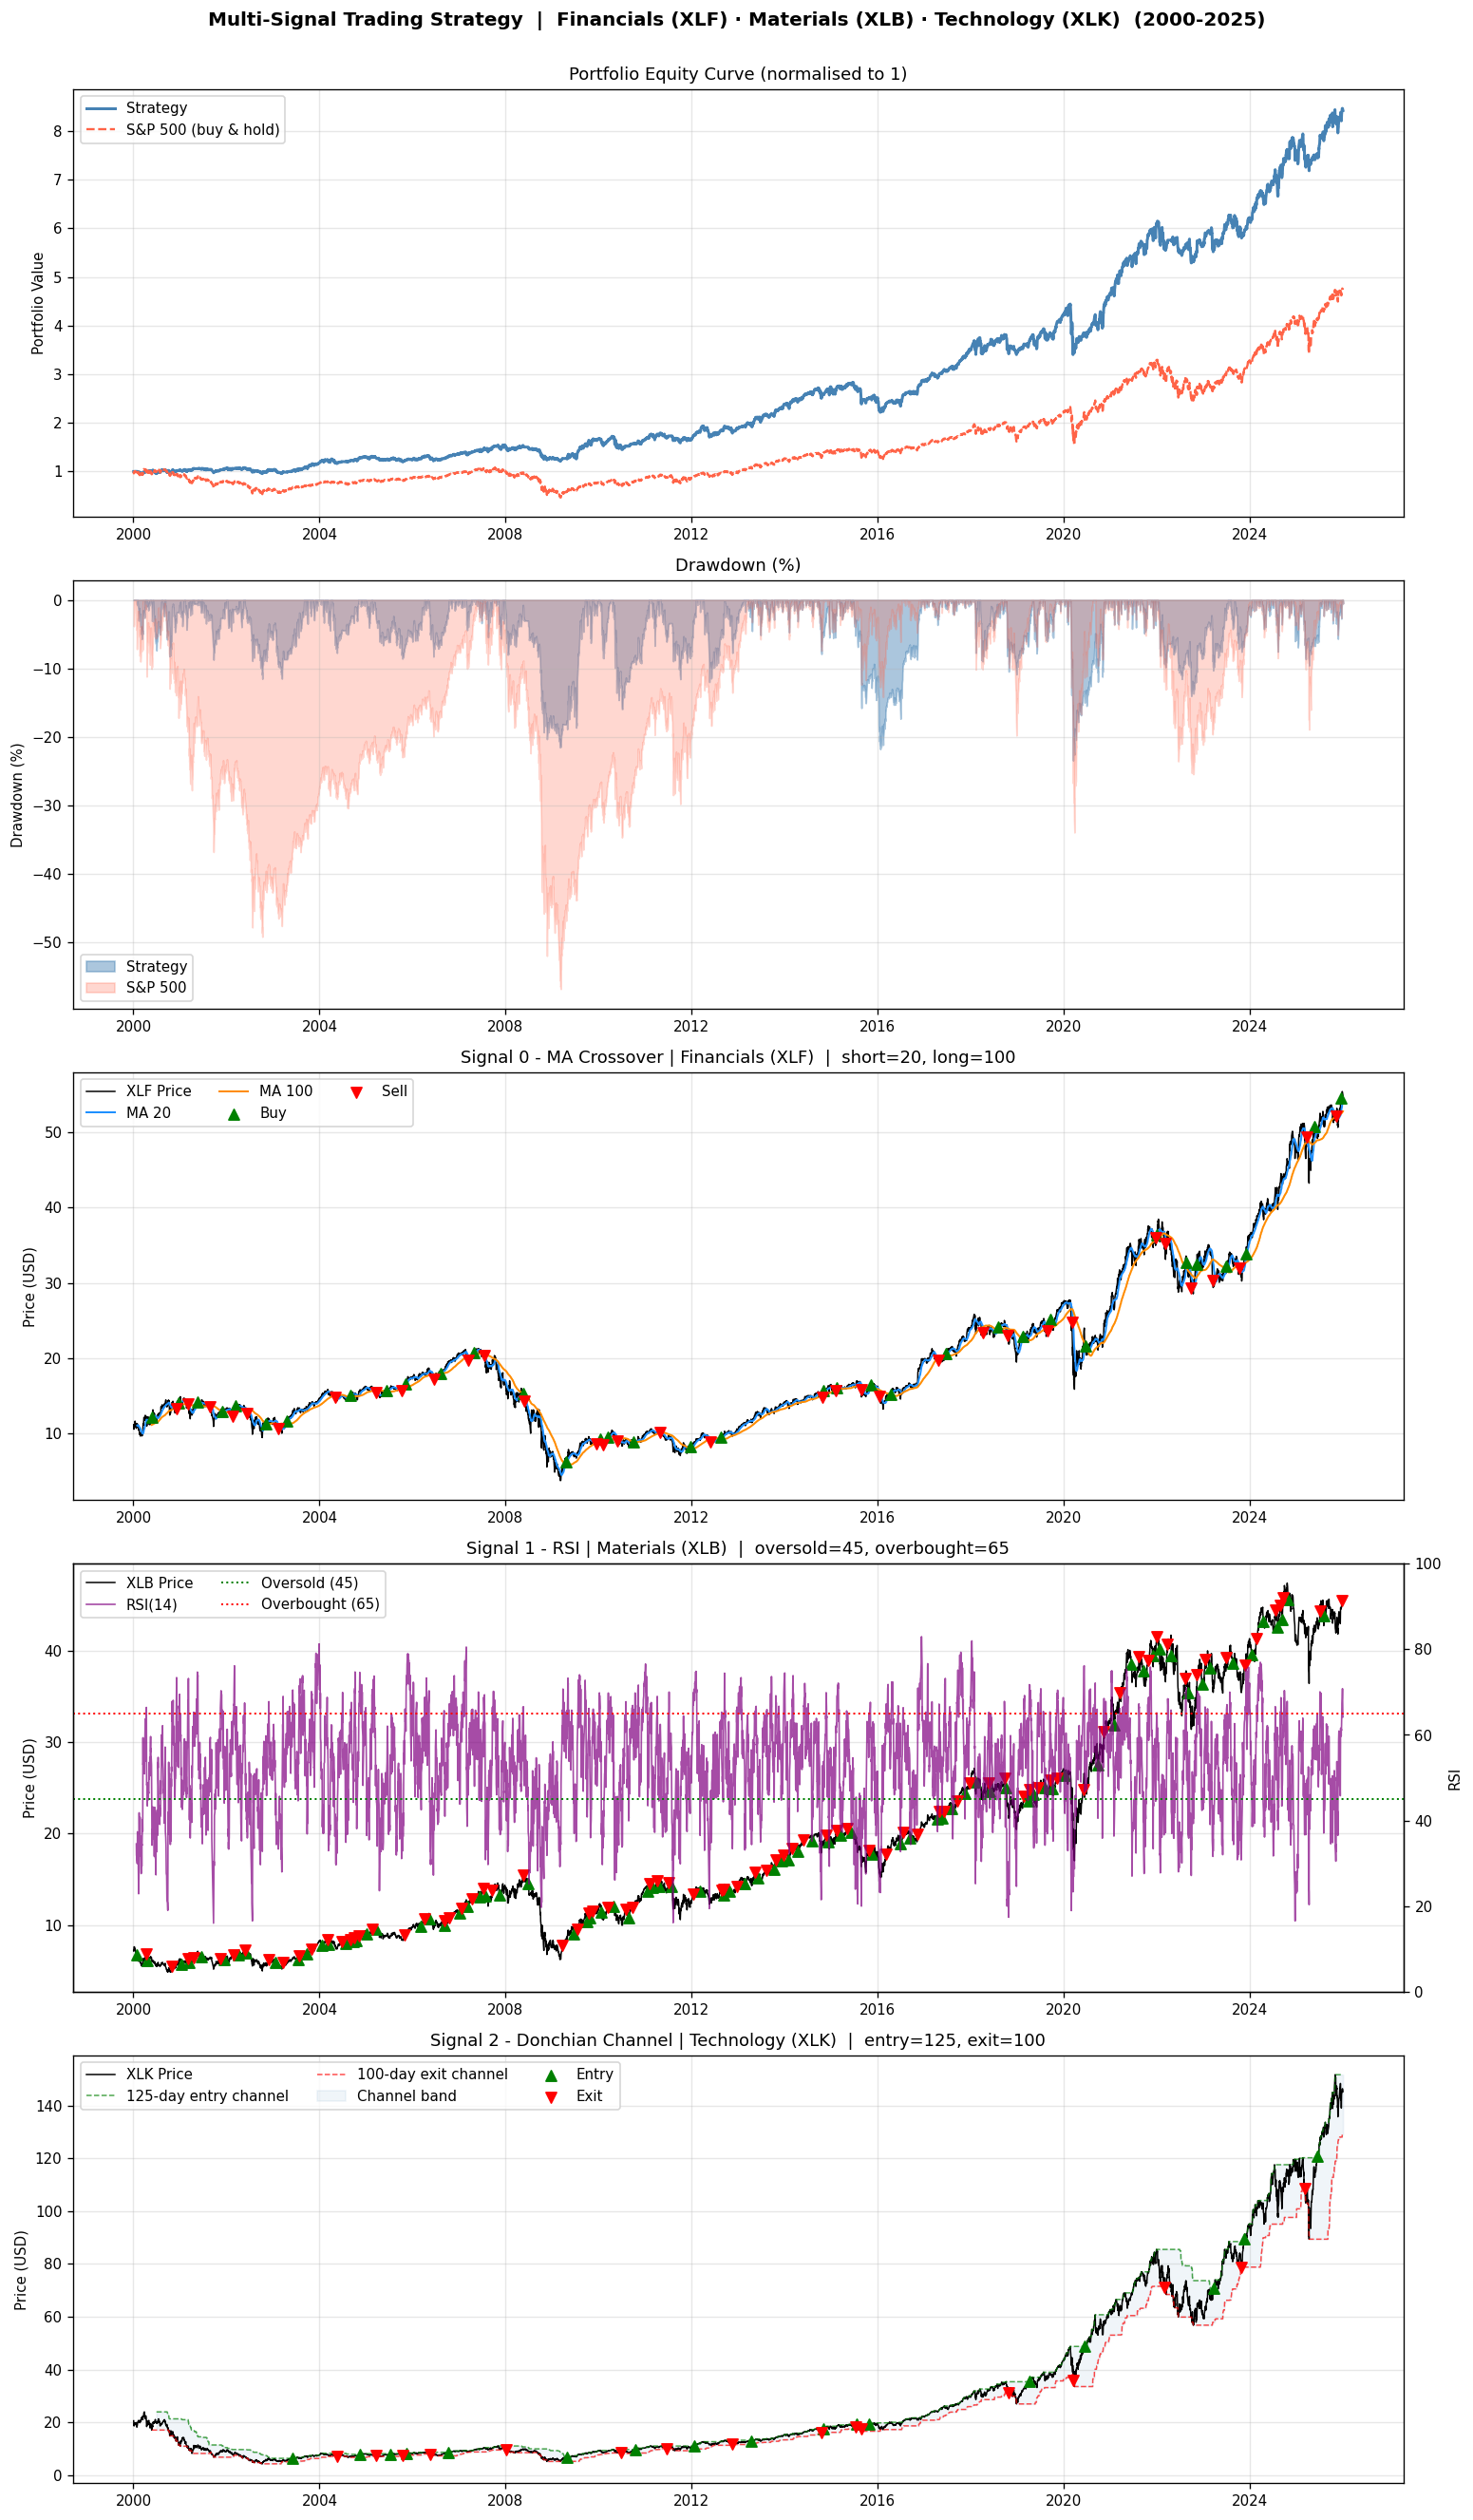

In [41]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

# pv_all, spx_values_all, dates_all are computed in the Performance Summary cell above

fig, axes = plt.subplots(5, 1, figsize=(13, 22))
fig.suptitle('Multi-Signal Trading Strategy  |  Financials (XLF) · Materials (XLB) · Technology (XLK)  (2000-2025)',
             fontsize=12, fontweight='bold', y=1.002)

# 1. Equity Curve
ax = axes[0]
ax.plot(dates_all, pv_all,         label='Strategy',             color='steelblue', lw=1.8)
ax.plot(dates_all, spx_values_all, label='S&P 500 (buy & hold)', color='tomato',
        lw=1.4, linestyle='--')
ax.set_title('Portfolio Equity Curve (normalised to 1)')
ax.set_ylabel('Portfolio Value')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[1]
dd_strat = module.compute_drawdown_series(pv_all)
dd_spx   = module.compute_drawdown_series(spx_values_all)
ax.fill_between(dates_all, dd_strat * 100, 0, color='steelblue', alpha=0.45, label='Strategy')
ax.fill_between(dates_all, dd_spx   * 100, 0, color='tomato',    alpha=0.25, label='S&P 500')
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 3. Signal 0: MA Crossover - XLF
ax = axes[2]
rep0 = FINANCE_TICKERS[0]
sig0 = _signals_full[rep0]
ax.plot(dates_all, df_prices_all[rep0], label=f'{rep0} Price', color='black', lw=0.9)
ax.plot(dates_all, sig0['short_ma'], label=f'MA {best_ma["short_window"]}',
        color='dodgerblue', lw=1.2)
ax.plot(dates_all, sig0['long_ma'],  label=f'MA {best_ma["long_window"]}',
        color='darkorange', lw=1.2)
buy_mask  = sig0['position_change'] > 0
sell_mask = sig0['position_change'] < 0
ax.scatter(dates_all[buy_mask],  df_prices_all[rep0][buy_mask],  marker='^', color='green', zorder=5, s=45, label='Buy')
ax.scatter(dates_all[sell_mask], df_prices_all[rep0][sell_mask], marker='v', color='red',   zorder=5, s=45, label='Sell')
ax.set_title(f'Signal 0 - MA Crossover | Financials (XLF)  |  '
             f'short={best_ma["short_window"]}, long={best_ma["long_window"]}')
ax.set_ylabel('Price (USD)')
ax.legend(ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 4. Signal 1: RSI - XLB
ax4a = axes[3]
ax4b = ax4a.twinx()
rep1 = MATERIALS_TICKERS[0]
sig1 = _signals_full[rep1]
ax4a.plot(dates_all, df_prices_all[rep1], color='black', lw=0.9, label=f'{rep1} Price')
buy_mask  = sig1['position_change'] > 0
sell_mask = sig1['position_change'] < 0
ax4a.scatter(dates_all[buy_mask],  df_prices_all[rep1][buy_mask],  marker='^', color='green', zorder=5, s=45)
ax4a.scatter(dates_all[sell_mask], df_prices_all[rep1][sell_mask], marker='v', color='red',   zorder=5, s=45)
ax4b.plot(dates_all, sig1['rsi'], color='purple', lw=1.0, alpha=0.7, label='RSI(14)')
ax4b.axhline(best_rsi['oversold'],   color='green', linestyle=':', lw=1.2, label=f'Oversold ({best_rsi["oversold"]})')
ax4b.axhline(best_rsi['overbought'], color='red',   linestyle=':', lw=1.2, label=f'Overbought ({best_rsi["overbought"]})')
ax4b.set_ylim(0, 100)
ax4b.set_ylabel('RSI')
ax4a.set_title(f'Signal 1 - RSI | Materials (XLB)  |  '
               f'oversold={best_rsi["oversold"]}, overbought={best_rsi["overbought"]}')
ax4a.set_ylabel('Price (USD)')
lines1, labels1 = ax4a.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4a.legend(lines1 + lines2, labels1 + labels2, ncol=2)
ax4a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4a.grid(alpha=0.3)

# 5. Signal 2: Donchian Channel - XLK
ax5 = axes[4]
rep2 = TECHNOLOGY_TICKERS[0]
sig2 = _signals_full[rep2]
ew2     = best_donchian['entry_window']
xw2     = best_donchian['exit_window']
ch_high = sig2['entry_high'].to_numpy()
ch_low  = sig2['exit_low'].to_numpy()
ax5.plot(dates_all, df_prices_all[rep2], color='black', lw=0.9, label=f'{rep2} Price')
ax5.plot(dates_all, ch_high, color='green', lw=0.9, linestyle='--', alpha=0.7, label=f'{ew2}-day entry channel')
ax5.plot(dates_all, ch_low,  color='red',   lw=0.9, linestyle='--', alpha=0.7, label=f'{xw2}-day exit channel')
ax5.fill_between(dates_all, ch_high, ch_low, alpha=0.08, color='steelblue', label='Channel band')
buy_mask  = sig2['position_change'] > 0
sell_mask = sig2['position_change'] < 0
ax5.scatter(dates_all[buy_mask],  df_prices_all[rep2][buy_mask],  marker='^', color='green', zorder=5, s=45, label='Entry')
ax5.scatter(dates_all[sell_mask], df_prices_all[rep2][sell_mask], marker='v', color='red',   zorder=5, s=45, label='Exit')
ax5.set_title(f'Signal 2 - Donchian Channel | Technology (XLK)  |  entry={ew2}, exit={xw2}')
ax5.set_ylabel('Price (USD)')
ax5.legend(ncol=3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Robustness

### Parameter Sensitivity

The heatmaps show IS Sortino across the full parameter grid. A smooth plateau around the chosen parameters (★) confirms the signals are robust.

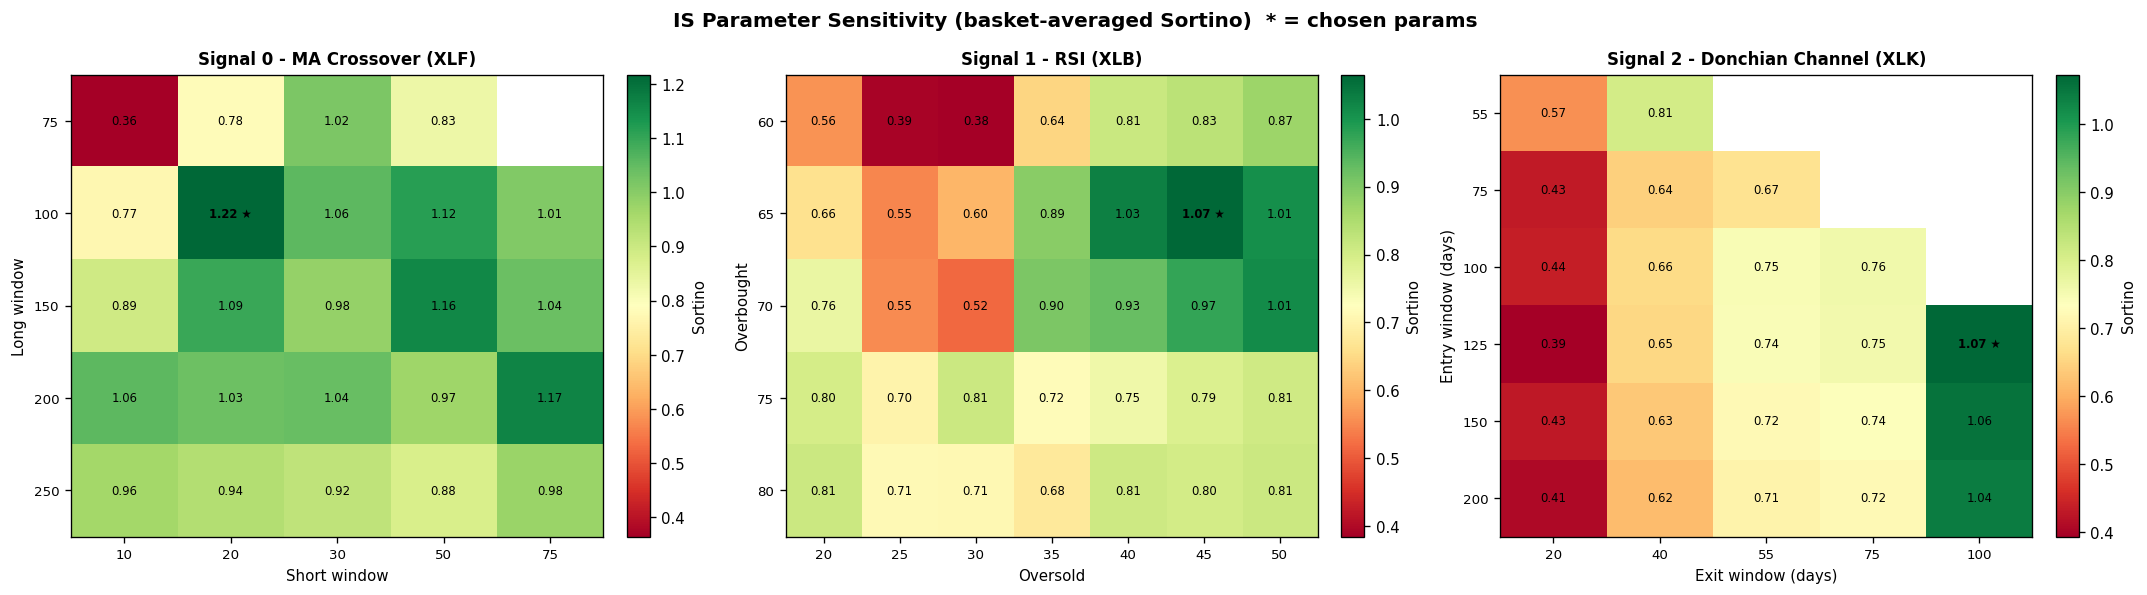

In [42]:
# IS sensitivity sweep - basket-averaged Sortino across the full parameter grid

short_windows = [10, 20, 30, 50, 75]
long_windows  = [75, 100, 150, 200, 250]
ma_sharpe = np.full((len(long_windows), len(short_windows)), np.nan)
for li, lw in enumerate(long_windows):
    for si, sw in enumerate(short_windows):
        if sw >= lw: continue
        ma_sharpe[li, si] = module.basket_sortino(module.ma_signal,
                                                   df_prices[FINANCE_TICKERS][is_mask],
                                                   short_window=sw, long_window=lw)

oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
rsi_sharpe = np.full((len(overbought_levels), len(oversold_levels)), np.nan)
for oi, ob in enumerate(overbought_levels):
    for si, os_ in enumerate(oversold_levels):
        if os_ >= ob: continue
        rsi_sharpe[oi, si] = module.basket_sortino(module.rsi_signal,
                                                    df_prices[MATERIALS_TICKERS][is_mask],
                                                    period=14, oversold=os_, overbought=ob)

don_ew_vals = [55, 75, 100, 125, 150, 200]
don_xw_vals = [20, 40, 55, 75, 100]
donchian_mat = np.full((len(don_ew_vals), len(don_xw_vals)), np.nan)
for ei, ew in enumerate(don_ew_vals):
    for xi, xw in enumerate(don_xw_vals):
        if xw >= ew:
            continue
        donchian_mat[ei, xi] = module.basket_sortino(module.donchian_signal,
                                                      df_prices[TECHNOLOGY_TICKERS][is_mask],
                                                      entry_window=ew, exit_window=xw)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IS Parameter Sensitivity (basket-averaged Sortino)  * = chosen params',
             fontsize=12, fontweight='bold')

module.draw_heatmap(axes[0], ma_sharpe,
             [str(l) for l in long_windows], [str(s) for s in short_windows],
             'Long window', 'Short window',
             'Signal 0 - MA Crossover (XLF)',
             star_row=long_windows.index(best_ma['long_window']),
             star_col=short_windows.index(best_ma['short_window']))

module.draw_heatmap(axes[1], rsi_sharpe,
             [str(o) for o in overbought_levels], [str(o) for o in oversold_levels],
             'Overbought', 'Oversold',
             'Signal 1 - RSI (XLB)',
             star_row=overbought_levels.index(best_rsi['overbought']),
             star_col=oversold_levels.index(best_rsi['oversold']))

module.draw_heatmap(axes[2], donchian_mat,
             [str(ew) for ew in don_ew_vals],
             [str(xw) for xw in don_xw_vals],
             'Entry window (days)', 'Exit window (days)',
             'Signal 2 - Donchian Channel (XLK)',
             star_row=don_ew_vals.index(best_donchian['entry_window']),
             star_col=don_xw_vals.index(best_donchian['exit_window']))

plt.tight_layout()
plt.show()

---
## 5. Walk-Forward Validation

We fix parameters on IS data and evaluate once on held-out OOS data.

| Period | Dates | Role |
|--------|-------|------|
| $\mathcal{D}_{IS}$ | 2010-2019 | Parameter optimisation |
| $\mathcal{D}_{OOS1}$ | 2020-2025 | Held-out evaluation |
| $\mathcal{D}_{OOS2}$ | 2000-2009 | Pre-sample stress test |


In [43]:
train_end  = '2019-12-31'
test_start = '2020-01-01'
oos2_start = '2000-01-01'
oos2_end   = '2009-12-31'


def period_stats(label, df_p, df_pc):
    tks_traded = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS
    sigs = {}
    for t in FINANCE_TICKERS:    sigs[t] = signal_0(df_p[t])
    for t in MATERIALS_TICKERS:  sigs[t] = signal_1(df_p[t])
    for t in TECHNOLOGY_TICKERS: sigs[t] = signal_2(df_p[t])

    pos_chg = pd.concat([sigs[t]['position_change'].rename(t) for t in tks_traded], axis=1)
    df_pos  = module.run_portfolio(df_p[tks_traded], df_pc, pos_chg)
    pv      = df_pos.to_numpy().sum(axis=1)
    dr      = pv[1:] / pv[:-1] - 1
    spx_p   = df_p['^GSPC'].to_numpy()
    spx_v   = spx_p / spx_p[0]
    spx_r   = spx_p[1:] / spx_p[:-1] - 1

    total_ret     = pv[-1] / pv[0] - 1
    spx_total_ret = spx_v[-1] - 1

    W = 46
    print(f'  {label}')
    print(f'  {"Metric":<18} {"Strategy":>9}  {"S&P 500":>9}')
    print('  ' + '-' * (W - 2))
    print(f'  {"Total Return":<18} {total_ret:>9.1%}  {spx_total_ret:>9.1%}')
    print(f'  {"CAGR":<18} {module.compute_cagr(pv):>9.1%}  {module.compute_cagr(spx_v):>9.1%}')
    print(f'  {"Sharpe":<18} {module.compute_sharpe(dr):>9.2f}  {module.compute_sharpe(spx_r):>9.2f}')
    print(f'  {"Sortino":<18} {module.compute_sortino(dr):>9.2f}  {module.compute_sortino(spx_r):>9.2f}')
    print(f'  {"Calmar":<18} {module.compute_calmar(pv):>9.2f}  {module.compute_calmar(spx_v):>9.2f}')
    print(f'  {"Ann. Volatility":<18} {module.compute_annual_volatility(dr):>9.1%}  {module.compute_annual_volatility(spx_r):>9.1%}')
    print(f'  {"Max Drawdown":<18} {module.compute_max_drawdown(pv):>9.1%}  {module.compute_max_drawdown(spx_v):>9.1%}')
    print()


# Load extended price data (2000-2025) for OOS2 via module.load_etf (downloads if CSV absent)
_fin_ext  = module.load_etf(FINANCE_TICKERS,    'xlf_ext.csv',         '2000-01-01', '2025-12-31', data_dir)
_mats_ext = module.load_etf(MATERIALS_TICKERS,  'xlb_ext.csv',         '2000-01-01', '2025-12-31', data_dir)
_tech_ext = module.load_etf(TECHNOLOGY_TICKERS, 'xlk_ext.csv',         '2000-01-01', '2025-12-31', data_dir)
_spx_ext  = module.load_etf(['^GSPC'],           'spx_ext.csv',         '2000-01-01', '2025-12-31', data_dir)
df_prices_ext = (_fin_ext.join(_mats_ext, how='outer')
                          .join(_tech_ext, how='outer')
                          .join(_spx_ext,  how='outer')
                          .ffill().dropna())
df_prices_ext.index = pd.to_datetime(df_prices_ext.index)

oos2_mask  = (df_prices_ext.index >= oos2_start) & (df_prices_ext.index <= oos2_end)
df_oos2    = df_prices_ext[oos2_mask]
df_pc_oos2 = module.make_price_changes(df_oos2)


print('=' * 48)
print('  Walk-Forward Validation')
print('=' * 48)
train_mask = df_prices.index <= train_end
period_stats('IN-SAMPLE   (2010-2019)',
             df_prices[train_mask],
             df_price_changes[train_mask])

test_mask = df_prices.index >= test_start
period_stats('OOS1  OUT-OF-SAMPLE (2020-2025)',
             df_prices[test_mask],
             df_price_changes[test_mask])

period_stats('OOS2  PRE-SAMPLE STRESS (2000-2009)',
             df_oos2,
             df_pc_oos2)
print('=' * 48)

  Walk-Forward Validation
  IN-SAMPLE   (2010-2019)
  Metric              Strategy    S&P 500
  --------------------------------------------
  Total Return          176.0%     185.2%
  CAGR                   10.7%      11.1%
  Sharpe                  0.95       0.79
  Sortino                 1.33       1.10
  Calmar                  0.49       0.56
  Ann. Volatility        11.3%      14.8%
  Max Drawdown          -21.8%     -19.8%

  OOS1  OUT-OF-SAMPLE (2020-2025)
  Metric              Strategy    S&P 500
  --------------------------------------------
  Total Return          114.7%     111.7%
  CAGR                   13.6%      13.4%
  Sharpe                  1.09       0.70
  Sortino                 1.59       0.99
  Calmar                  0.98       0.39
  Ann. Volatility        12.4%      20.9%
  Max Drawdown          -13.9%     -33.9%

  OOS2  PRE-SAMPLE STRESS (2000-2009)
  Metric              Strategy    S&P 500
  --------------------------------------------
  Total Return     

---

**References:**
- Bailey, D. H., & Lopez de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5), 94–107.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3), 793–805.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1), 5–32.
- Shleifer, A., & Vishny, R. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.